In [1]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkat/Final_Data"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
model = models.alexnet(pretrained=True)

# Modify classifier for 4 classes
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 4)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 209MB/s] 


In [7]:

from sklearn.utils.class_weight import compute_class_weight

labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [8]:
def train_model(model, train_loader, val_loader, epochs=30):
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return model

In [9]:
model = train_model(model, train_loader, val_loader, epochs=30)

Epoch 1/30 | Loss: 127.3012 | Train Acc: 0.7715 | Val Acc: 0.8496
Epoch 2/30 | Loss: 96.2643 | Train Acc: 0.8298 | Val Acc: 0.8533
Epoch 3/30 | Loss: 88.9736 | Train Acc: 0.8392 | Val Acc: 0.8608
Epoch 4/30 | Loss: 82.3781 | Train Acc: 0.8525 | Val Acc: 0.8905
Epoch 5/30 | Loss: 78.3888 | Train Acc: 0.8582 | Val Acc: 0.8688
Epoch 6/30 | Loss: 74.7717 | Train Acc: 0.8653 | Val Acc: 0.8886
Epoch 7/30 | Loss: 71.5199 | Train Acc: 0.8731 | Val Acc: 0.8750
Epoch 8/30 | Loss: 67.4951 | Train Acc: 0.8777 | Val Acc: 0.8843
Epoch 9/30 | Loss: 64.5994 | Train Acc: 0.8814 | Val Acc: 0.8942
Epoch 10/30 | Loss: 62.9344 | Train Acc: 0.8923 | Val Acc: 0.8781
Epoch 11/30 | Loss: 60.8114 | Train Acc: 0.8912 | Val Acc: 0.8991
Epoch 12/30 | Loss: 57.7503 | Train Acc: 0.9001 | Val Acc: 0.8886
Epoch 13/30 | Loss: 57.6252 | Train Acc: 0.8955 | Val Acc: 0.8998
Epoch 14/30 | Loss: 54.3602 | Train Acc: 0.9043 | Val Acc: 0.9041
Epoch 15/30 | Loss: 49.9472 | Train Acc: 0.9118 | Val Acc: 0.9041
Epoch 16/30 | Loss

In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       1.00      0.99      1.00       405
             Normal       0.96      0.98      0.97       405
Pneumonia-Bacterial       0.84      0.80      0.82       405
    Pneumonia-Viral       0.80      0.82      0.81       405

           accuracy                           0.90      1620
          macro avg       0.90      0.90      0.90      1620
       weighted avg       0.90      0.90      0.90      1620



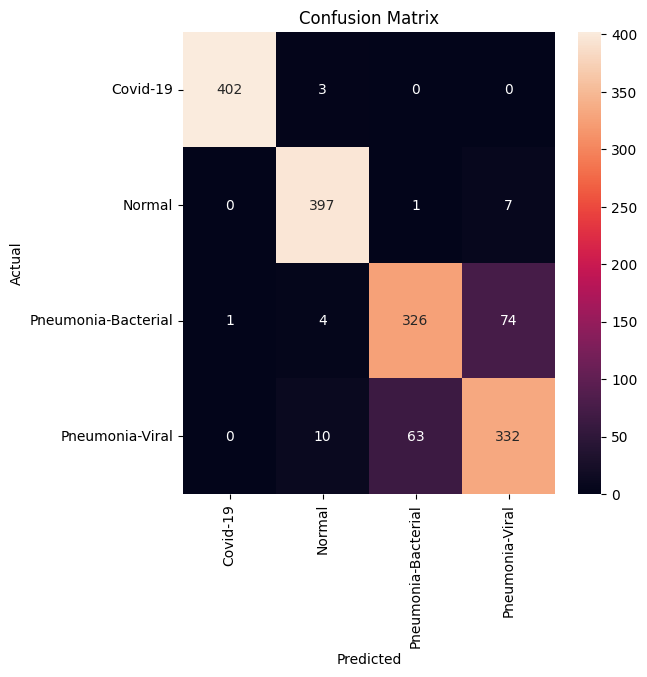

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()